# Fuzzy Logic Model - Habitat Suitability for Plecoptera: Perlidae

This notebook builds a Mamdani fuzzy inference system that predicts the **presence/absence** of *Plecoptera: Perlidae* in the Cali River from five physicochemical predictors (BOD5, DO, turbidity, conductivity and TDS).

Predictor membership functions are defined from expert criteria, and the rule base is generated automatically (one rule per observation). The model is evaluated **in sample** (see the Limitations section).

## Data Loading

In [1]:
import pandas as pd

# Cali River macroinvertebrate dataset (source: CVC)
file_path = "../../data/DB - Macroinvertebrados.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()
df

,COT,DBO5,DBOU,DBO5s,DQO,Dureza,Fósforo,Fosfatos,Hierro,Magnesio,...,pH,Conductividad,OD,Temperatura,Coliformes,Profundidad,Velocidad,Caudal,Perlidae,Trichoptera
0,1.69,2,4,2,10.00,35.5,0.114,0.015,0.236,3.530,...,7.14,80,6.30,15.00,1012,0.44,0.55,1.39,1,0
1,5.24,7,9,5,14.79,124.0,1.640,0.758,6.680,17.400,...,7.40,469,4.33,25.86,11199,0.29,0.52,1.33,0,0
2,2.80,2,3,2,10.00,43.9,0.162,0.155,5.100,2.920,...,7.30,150,5.92,17.00,41,0.32,0.45,0.80,1,1
3,7.92,3,4,2,13.71,113.0,0.050,0.150,0.600,11.800,...,7.92,371,6.82,22.87,9804,0.33,0.71,0.92,0,0
4,12.20,8,10,7,10.00,46.4,0.580,0.150,0.233,3.920,...,7.38,110,6.50,18.40,24196,0.54,0.42,1.69,0,0
5,11.00,2,5,2,10.00,49.4,0.149,0.191,0.831,4.740,...,6.89,115,7.69,20.30,6867,0.36,0.32,1.59,0,0
6,4.33,35,26,15,70.60,108.0,1.500,1.080,0.195,0.378,...,6.94,300,5.05,25.23,19863,0.34,0.66,0.97,0,0
7,7.38,14,35,12,88.50,216.0,0.256,0.221,17.500,24.600,...,7.15,500,3.20,29.30,24196,0.49,0.76,1.50,0,0
8,7.20,2,3,2,10.00,47.5,0.443,0.221,0.100,5.540,...,8.16,112,5.90,18.62,676,0.46,0.42,0.87,0,0
9,3.04,2,3,2,10.00,98.4,0.050,0.150,0.411,11.400,...,7.90,294,7.01,19.94,2613,0.38,0.82,0.83,0,1


In [2]:
# Keep the predictors and the binary Perlidae response
columns_needed = ['OD', 'DBO5', 'SDT', 'Turbiedad', 'Conductividad', 'Perlidae']
filtered_df = df[columns_needed]

print("First rows of the filtered dataset:")
display(filtered_df.head())
print("\nDescriptive statistics:")
display(filtered_df.describe())

First rows of the filtered dataset:


,OD,DBO5,SDT,Turbiedad,Conductividad,Perlidae
0,6.30,2,50,2.71,80,1
1,4.33,7,120,11.30,469,0
2,5.92,2,53,2.00,150,1
3,6.82,3,124,10.60,371,0
4,6.50,8,97,6.69,110,0



Descriptive statistics:


,OD,DBO5,SDT,Turbiedad,Conductividad,Perlidae
count,18.000000,18.000000,18.000000,18.000000,18.000000,18.000000
mean,5.925000,6.000000,125.666667,17.779444,263.500000,0.333333
std,1.093619,8.512966,87.982619,25.965117,175.512108,0.485071
min,3.200000,2.000000,50.000000,2.000000,80.000000,0.000000
25%,5.377500,2.000000,89.500000,2.177500,141.000000,0.000000
50%,6.060000,2.000000,105.500000,6.690000,207.000000,0.000000
75%,6.672500,6.000000,117.250000,11.150000,300.000000,1.000000
max,7.690000,35.000000,410.000000,88.100000,766.000000,1.000000


### Outlier removal

Excessively high values are trimmed with an IQR rule using a tolerant upper bound (2.5 x IQR). After this step the dataset contains 14 observations.

In [3]:
def remove_excessive_outliers(df, column, margin=2.5):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + margin * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

columns_needed = ['DBO5', 'Turbiedad', 'Conductividad', 'OD', 'SDT', 'Perlidae']
filtered_df = df[columns_needed]
filtered_df_cleaned = filtered_df.copy()
for column in ['DBO5', 'Turbiedad', 'Conductividad', 'OD', 'SDT']:
    filtered_df_cleaned = remove_excessive_outliers(filtered_df_cleaned, column, margin=2.5)

print(f"Original dataset size: {len(filtered_df)}")
print(f"Size after outlier removal: {len(filtered_df_cleaned)}")
print("\nDescriptive statistics of the clean dataset:")
print(filtered_df_cleaned.describe())

Original dataset size: 18
Size after outlier removal: 14

Descriptive statistics of the clean dataset:
            DBO5  Turbiedad  Conductividad         OD         SDT   Perlidae
count  14.000000  14.000000      14.000000  14.000000   14.000000  14.000000
mean    2.857143   6.866429     218.714286   6.057143   91.928571   0.428571
std     1.994498   7.549631     112.240421   0.821859   25.817300   0.513553
min     2.000000   2.000000      80.000000   4.330000   50.000000   0.000000
25%     2.000000   2.000000     141.000000   5.592500   73.500000   0.000000
50%     2.000000   3.820000     196.500000   6.250000  103.500000   0.000000
75%     2.000000   9.472500     293.500000   6.672500  107.000000   1.000000
max     8.000000  30.100000     469.000000   7.010000  124.000000   1.000000


## Model Definition

The predictor membership functions are identical to those used in the other fuzzy models. The output is a binary fuzzy variable (Absent / Present) with a 0.5 membership threshold.

In [4]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Input variables (antecedents): universes and triangular membership functions
dbo5 = ctrl.Antecedent(np.arange(0, 9.1, 0.1), 'DBO5')
od = ctrl.Antecedent(np.arange(5, 7.6, 0.1), 'OD')
turbiedad = ctrl.Antecedent(np.arange(0, 31.1, 0.1), 'Turbiedad')
conductividad = ctrl.Antecedent(np.arange(50, 501, 1), 'Conductividad')
sdt = ctrl.Antecedent(np.arange(30, 131, 1), 'SDT')

# Biochemical Oxygen Demand (BOD5)
dbo5['Bajo'] = fuzz.trimf(dbo5.universe, [0, 2, 3])
dbo5['Medio'] = fuzz.trimf(dbo5.universe, [2.5, 4, 6])
dbo5['Alto'] = fuzz.trimf(dbo5.universe, [5, 7, 9])

# Dissolved Oxygen (DO)
od['Bajo'] = fuzz.trimf(od.universe, [4, 5, 5.8])
od['Medio'] = fuzz.trimf(od.universe, [5.5, 6.3, 6.9])
od['Alto'] = fuzz.trimf(od.universe, [6.5, 7, 7.5])

# Turbidity
turbiedad['Baja'] = fuzz.trimf(turbiedad.universe, [0, 2, 5])
turbiedad['Media'] = fuzz.trimf(turbiedad.universe, [4, 8, 12])
turbiedad['Alta'] = fuzz.trimf(turbiedad.universe, [10, 20, 31])

# Conductivity
conductividad['Baja'] = fuzz.trimf(conductividad.universe, [50, 80, 150])
conductividad['Media'] = fuzz.trimf(conductividad.universe, [100, 250, 400])
conductividad['Alta'] = fuzz.trimf(conductividad.universe, [300, 450, 500])

# Total Dissolved Solids (TDS)
sdt['Bajo'] = fuzz.trimf(sdt.universe, [30, 50, 70])
sdt['Medio'] = fuzz.trimf(sdt.universe, [60, 90, 110])
sdt['Alto'] = fuzz.trimf(sdt.universe, [100, 120, 130])

# Output variable (consequent): presence/absence of Plecoptera: Perlidae
perlidae = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'Perlidae')
perlidae['Ausente'] = fuzz.trimf(perlidae.universe, [0, 0, 0.5])
perlidae['Presente'] = fuzz.trimf(perlidae.universe, [0.5, 1, 1])

## Predictor Categorisation

In [5]:
import skfuzzy as fuzz

# Generic helper: assign a crisp value to the linguistic category with the
# highest membership degree under the previously defined membership functions.
def categorize_variable(value, universe, mf_dict):
    memberships = {cat: fuzz.interp_membership(universe, mf, value)
                   for cat, mf in mf_dict.items()}
    return max(memberships, key=memberships.get)

def categorize_dbo5(value):
    return categorize_variable(value, dbo5.universe,
        {'Bajo': dbo5['Bajo'].mf, 'Medio': dbo5['Medio'].mf, 'Alto': dbo5['Alto'].mf})

def categorize_od(value):
    return categorize_variable(value, od.universe,
        {'Bajo': od['Bajo'].mf, 'Medio': od['Medio'].mf, 'Alto': od['Alto'].mf})

def categorize_turbiedad(value):
    return categorize_variable(value, turbiedad.universe,
        {'Baja': turbiedad['Baja'].mf, 'Media': turbiedad['Media'].mf, 'Alta': turbiedad['Alta'].mf})

def categorize_conductividad(value):
    return categorize_variable(value, conductividad.universe,
        {'Baja': conductividad['Baja'].mf, 'Media': conductividad['Media'].mf, 'Alta': conductividad['Alta'].mf})

def categorize_sdt(value):
    return categorize_variable(value, sdt.universe,
        {'Bajo': sdt['Bajo'].mf, 'Medio': sdt['Medio'].mf, 'Alto': sdt['Alto'].mf})

def categorize_row(row):
    return {
        'DBO5': categorize_dbo5(row['DBO5']),
        'OD': categorize_od(row['OD']),
        'Turbiedad': categorize_turbiedad(row['Turbiedad']),
        'Conductividad': categorize_conductividad(row['Conductividad']),
        'SDT': categorize_sdt(row['SDT']),
        'Perlidae': row['Perlidae'],
    }

categorized_df = filtered_df_cleaned.apply(categorize_row, axis=1, result_type='expand')
print(categorized_df)

     DBO5     OD Turbiedad Conductividad    SDT  Perlidae
0    Bajo  Medio      Baja          Baja   Bajo       1.0
1    Alto   Bajo     Media          Alta   Alto       0.0
2    Bajo  Medio      Baja         Media   Bajo       1.0
3   Medio   Alto     Media          Alta   Alto       0.0
4    Alto  Medio     Media          Baja  Medio       0.0
8    Bajo  Medio      Baja          Baja  Medio       0.0
9    Bajo   Alto     Media         Media   Bajo       0.0
10   Bajo   Alto      Baja         Media  Medio       1.0
11   Bajo   Bajo      Baja         Media  Medio       1.0
12   Bajo   Alto      Baja         Media   Alto       1.0
13   Bajo  Medio      Baja         Media   Alto       1.0
14   Bajo   Bajo      Alta         Media   Alto       0.0
16   Bajo   Bajo     Media         Media  Medio       0.0
17   Bajo  Medio      Baja         Media   Alto       0.0


## Rule Generation

One fuzzy rule per observation: the antecedent is the conjunction of the categorised predictors and the consequent is Present/Absent according to the observed value.

In [6]:
rules = []
for _, row in categorized_df.iterrows():
    antecedent = (
        dbo5[row['DBO5']] &
        od[row['OD']] &
        turbiedad[row['Turbiedad']] &
        conductividad[row['Conductividad']] &
        sdt[row['SDT']]
    )
    consequent = perlidae['Presente'] if row['Perlidae'] == 1 else perlidae['Ausente']
    rules.append(ctrl.Rule(antecedent, consequent))

perlidae_ctrl = ctrl.ControlSystem(rules)
perlidae_sim = ctrl.ControlSystemSimulation(perlidae_ctrl)
print(f"{len(rules)} rules were generated for the fuzzy system.")

14 rules were generated for the fuzzy system.


## Evaluation

The model is run on every observation (in-sample). The defuzzified output is converted to a binary class using a threshold of 0.499.

In [7]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

predictions = []
real_values = filtered_df_cleaned['Perlidae']

for _, row in filtered_df_cleaned.iterrows():
    try:
        perlidae_sim.input['DBO5'] = row['DBO5']
        perlidae_sim.input['OD'] = row['OD']
        perlidae_sim.input['Turbiedad'] = row['Turbiedad']
        perlidae_sim.input['Conductividad'] = row['Conductividad']
        perlidae_sim.input['SDT'] = row['SDT']
        perlidae_sim.compute()
        prediction = perlidae_sim.output['Perlidae']
        predictions.append(1 if prediction >= 0.499 else 0)
    except Exception as e:
        print(f"Error with data: {row.to_dict()} - {e}")
        predictions.append(0)

print("Confusion matrix:")
print(confusion_matrix(real_values, predictions))
print("\nClassification report:")
print(classification_report(real_values, predictions))
print("\nAccuracy:")
print(accuracy_score(real_values, predictions))

Confusion matrix:
[[7 1]
 [0 6]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.88      0.93         8
           1       0.86      1.00      0.92         6

    accuracy                           0.93        14
   macro avg       0.93      0.94      0.93        14
weighted avg       0.94      0.93      0.93        14


Accuracy:
0.9285714285714286


### Performance indicators

In [8]:
from sklearn.metrics import roc_auc_score, cohen_kappa_score
from sklearn.preprocessing import label_binarize

cm = confusion_matrix(real_values, predictions)
print("Confusion matrix:")
print(cm)

cci = accuracy_score(real_values, predictions)
print(f"Correctly Classified Instances (CCI): {cci:.4f}")

kappa = cohen_kappa_score(real_values, predictions)
print(f"Cohen's Kappa: {kappa:.4f}")

tp = cm[1, 1]; tn = cm[0, 0]; fp = cm[0, 1]; fn = cm[1, 0]
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

real_bin = label_binarize(real_values, classes=[0, 1])
pred_bin = label_binarize(predictions, classes=[0, 1])
print(f"Area Under the Curve (AUC): {roc_auc_score(real_bin, pred_bin):.4f}")

Confusion matrix:
[[7 1]
 [0 6]]
Correctly Classified Instances (CCI): 0.9286
Cohen's Kappa: 0.8571
Sensitivity: 1.0000
Specificity: 0.8750
Area Under the Curve (AUC): 0.9375


## Visualisation

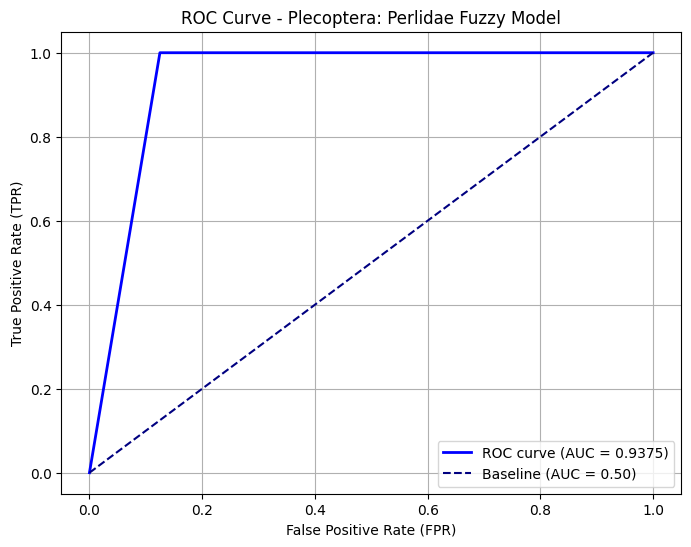

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(real_bin.ravel(), pred_bin.ravel())
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Baseline (AUC = 0.50)')
plt.title("ROC Curve - Plecoptera: Perlidae Fuzzy Model")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc="lower right")
plt.grid()
plt.show()

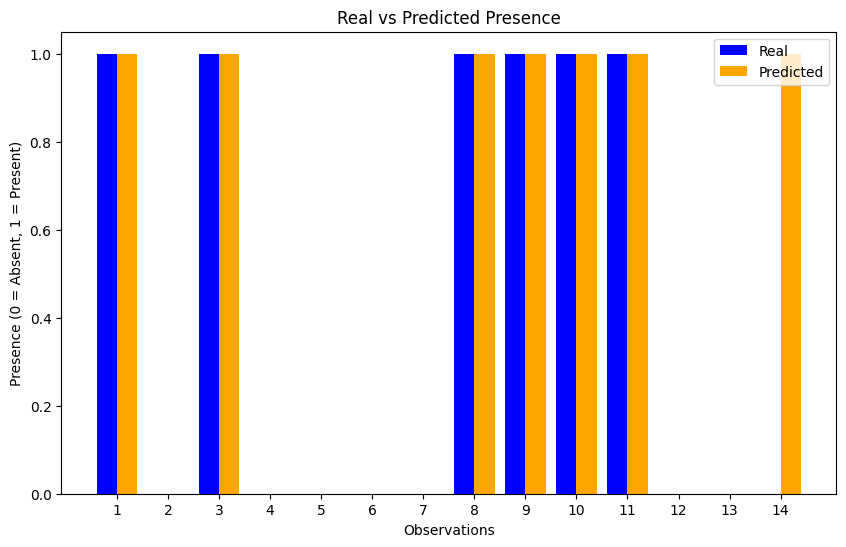

In [10]:
import numpy as np

# Real vs predicted presence per observation
real_array = filtered_df_cleaned['Perlidae'].values
indices = np.arange(1, len(real_array) + 1)

plt.figure(figsize=(10, 6))
plt.bar(indices - 0.2, real_array, width=0.4, label="Real", color='blue')
plt.bar(indices + 0.2, predictions, width=0.4, label="Predicted", color='orange')
plt.xlabel("Observations")
plt.ylabel("Presence (0 = Absent, 1 = Present)")
plt.title("Real vs Predicted Presence")
plt.xticks(indices)
plt.legend()
plt.show()

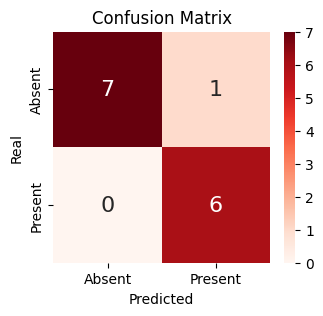

In [11]:
import seaborn as sns

cm = confusion_matrix(real_values, predictions)
plt.figure(figsize=(3.5, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', annot_kws={"size": 16},
            xticklabels=['Absent', 'Present'], yticklabels=['Absent', 'Present'])
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix")
plt.show()

## Limitations

Rules were derived from the same observations used for evaluation. Performance metrics therefore reflect in-sample fit and should not be interpreted as evidence of out-of-sample generalisation capacity.

A proper out-of-sample assessment (e.g. leave-one-out cross-validation) is a future improvement, not something implemented here.